In [2]:
# ==============================
# Cell 1: Imports and Setup
# ==============================

# Import necessary libraries
import numpy as np              # For numerical computation
import matplotlib.pyplot as plt # For plotting

# Set a random generator for reproducibility
rng = np.random.default_rng(42)


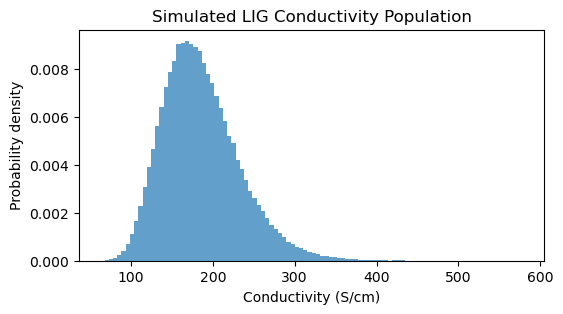

In [4]:
# ==============================
# Cell 2: Simulate LIG Conductivity Population
# ==============================

# Simulate a realistic population of LIG conductivity measurements
# Right-skewed distribution (log-normal), common for percolative transport
n_population = 200000  # total "raw measurements" in population
population = rng.lognormal(mean=np.log(180), sigma=0.25, size=n_population)

# Visualize the population
plt.figure(figsize=(6,3))
plt.hist(population, bins=100, density=True, alpha=0.7, color='C0')
plt.xlabel("Conductivity (S/cm)")
plt.ylabel("Probability density")
plt.title("Simulated LIG Conductivity Population")
plt.show()


In [5]:
# ==============================
# Cell 3: Generate LIG Samples
# ==============================

n_samples = 300  # number of LIG samples to study correlations

# Simulate physical features for each sample

# 1. Laser fluence (J/cm²)
fluence = rng.uniform(1.5, 4.0, n_samples)

# 2. ID/IG ratio (Raman disorder metric)
# Higher fluence → lower disorder
ID_IG = 1.1 - 0.15 * fluence + rng.normal(0, 0.05, n_samples)

# 3. Sheet resistance Rs (Ω/sq)
# More disorder → higher resistance
Rs = 80 + 60 * ID_IG + rng.normal(0, 5, n_samples)

# 4. Conductivity σ (S/cm)
# Inverse of sheet resistance
sigma = 1e4 / Rs

# Combine into a feature matrix
X = np.column_stack([fluence, ID_IG, Rs, sigma])
feature_names = ["Fluence", "ID/IG", "Rs", "σ"]

print(f"Feature matrix X has shape: {X.shape}")


Feature matrix X has shape: (300, 4)


In [7]:
# ==============================
# Cell 4: Compute Correlation Matrix
# ==============================

# Compute Pearson correlation coefficients (linear relationships)
cor = np.corrcoef(X, rowvar=False)

# Print correlation matrix
print("Correlation matrix:\n", cor)


Correlation matrix:
 [[ 1.         -0.89525656 -0.69021835  0.68695876]
 [-0.89525656  1.          0.78043144 -0.77529591]
 [-0.69021835  0.78043144  1.         -0.99671999]
 [ 0.68695876 -0.77529591 -0.99671999  1.        ]]


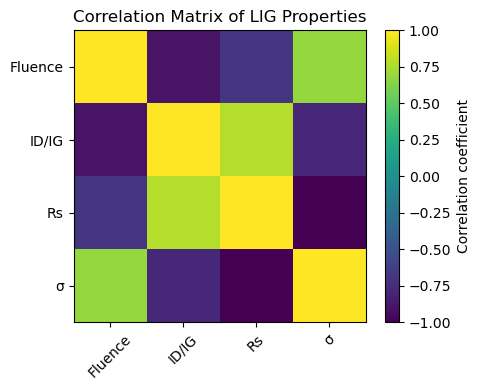

In [12]:
# ==============================
# Cell 5: Visualize Correlation Matrix
# ==============================

plt.figure(figsize=(5,4))
im = plt.imshow(cor, vmin=-1, vmax=1, cmap='viridis')
plt.colorbar(im, label="Correlation coefficient")
plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Correlation Matrix of LIG Properties")
plt.tight_layout()
plt.show()
